In [66]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow import keras
from sklearn.impute import SimpleImputer
from tensorflow.keras.layers import Dense,Input , Flatten , Dropout , BatchNormalization , ReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam,SGD
from tensorflow.keras.regularizers import l2 , l1
from tensorflow.keras.callbacks import EarlyStopping , ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import categorical_crossentropy, binary_crossentropy, binary_focal_crossentropy,categorical_focal_crossentropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score, roc_curve,auc
from sklearn.utils.class_weight import compute_class_weight 
from tensorflow.keras.utils import to_categorical
from ydata_profiling import ProfileReport
from tensorflow.keras.metrics import F1Score

In [67]:
df=pd.read_csv('water_potability).csv')

In [68]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,4.227537,201.447487,13122.329581,6.932558,374.843538,402.660774,22.823293,76.469426,4.479628,0
1,7.185168,209.683140,24909.783147,6.691070,NaN,501.785420,16.088648,75.671329,3.955847,1
2,8.460964,236.831781,13158.848362,5.478276,NaN,547.911680,16.741463,74.251544,4.728494,0
3,6.706695,232.926598,27881.504407,7.881448,337.111017,443.208774,14.523389,64.121740,4.371882,1
4,7.893313,220.348320,14444.289598,8.037400,300.152172,339.066071,18.423634,67.009098,4.097360,1


In [69]:
df.Potability.value_counts()

Potability
0    1998
1    1998
Name: count, dtype: int64

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3996 entries, 0 to 3995
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3395 non-null   float64
 1   Hardness         3996 non-null   float64
 2   Solids           3996 non-null   float64
 3   Chloramines      3996 non-null   float64
 4   Sulfate          3049 non-null   float64
 5   Conductivity     3996 non-null   float64
 6   Organic_carbon   3996 non-null   float64
 7   Trihalomethanes  3805 non-null   float64
 8   Turbidity        3996 non-null   float64
 9   Potability       3996 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 312.3 KB


In [71]:
df.Potability.value_counts()

Potability
0    1998
1    1998
Name: count, dtype: int64

In [72]:
X=df.drop("Potability",axis=1)
y=df['Potability']
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)
y=to_categorical(y)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

In [73]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [84]:
model = Sequential([
    
    Dense(128,activation='relu',input_shape=(9,)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(2,activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,138 (51.32 KB)

 Trainable params: 12,658 (49.45 KB)

 Non-trainable params: 480 (1.88 KB)

In [85]:
history=model.fit(X_train,y_train,validation_split=0.2,epochs=50,batch_size=32)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5246 - loss: 0.8945 - val_accuracy: 0.5375 - val_loss: 0.6816
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5481 - loss: 0.7673 - val_accuracy: 0.5844 - val_loss: 0.6744
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5575 - loss: 0.7297 - val_accuracy: 0.5813 - val_loss: 0.6666
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5704 - loss: 0.6987 - val_accuracy: 0.6172 - val_loss: 0.6472
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5794 - loss: 0.6828 - val_accuracy: 0.6234 - val_loss: 0.6423
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5994 - loss: 0.6700 - val_accuracy: 0.6484 - val_loss: 0.6300
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5990 - loss: 0.6532 - val_accuracy: 0.6516 - val_loss: 0.6222
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6182 - loss: 0.6440 - val_accuracy: 0.6656 - val_loss:

C:\Users\miana\AppData\Local\Temp\ipykernel_10648\2871961737.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


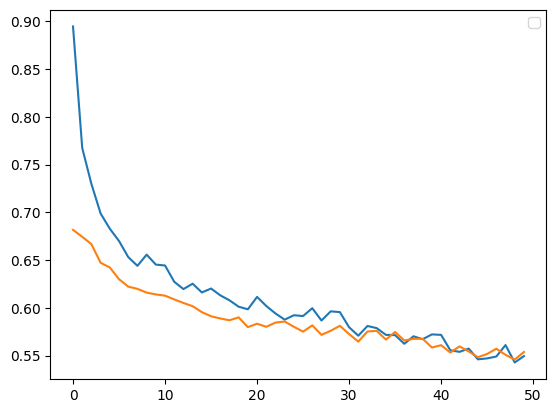

In [86]:
%matplotlib inline
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.legend()
plt.show()